# E.R.M.E.S. - Fase 1: Exploratory Data Analysis (EDA) e Data Understanding

In questo notebook viene eseguita l'analisi esplorativa del dataset **FER-2013**. L'obiettivo è validare l'integrità dei dati e identificare le criticità strutturali (bias) che influenzeranno la progettazione architetturale del modello di Machine Learning.

L'analisi è divisa in due macro-fasi:
1. **Data Validation & Distribution:** Scansione I/O alla ricerca di file corrotti, estrazione delle risoluzioni uniche e quantificazione dello sbilanciamento delle classi (*Class Imbalance*).
2. **Feature & Spatial Inspection:** Analisi quantitativa tramite Computer Vision classica per misurare il rumore strutturale (Face Detection Rate), i bias di illuminazione (Densità dei Pixel) e il disallineamento geometrico (Varianza del Laplaciano sui volti medi).

## 1. Acquisizione Dati e Analisi Strutturale
La prima fase del *Data Understanding* si concentra sull'infrastruttura del dataset. 
Prima di sviluppare qualsiasi pipeline di addestramento, è imperativo:
* Mappare la distribuzione delle classi per identificare il rapporto tra maggioranza e minoranza, definendo la necessità di metriche specifiche (es. F1-Score) e tecniche di *Cost-Sensitive Learning*.
* Garantire l'integrità fisica dei file (Sanity Check) per prevenire crash di I/O durante la lettura asincrona dei tensori.

In [1]:
"""
Modulo di inizializzazione dell'ambiente e configurazione globale.
Importa le dipendenze per l'elaborazione numerica (NumPy), Computer Vision (OpenCV)
e definisce lo stile globale per la Data Visualization.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
from typing import Tuple, Set, Dict

# Configurazione stile grafico
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# Configurazione del percorso principale verso i dati di training
base_dir = Path('../data/fer2013/train')

print("--- INIZIALIZZAZIONE AMBIENTE ---")
print(f"Percorso dataset risolto: {base_dir.resolve()}")

--- INIZIALIZZAZIONE AMBIENTE ---
Percorso dataset risolto: C:\Users\Ugo\Dropbox\PC\Desktop\UGO\Scuola\Unisa\Corsi di Studio\ANNO 3 SEMESTRE 1\Machine Learning\PROGETTO\ERMES\data\fer2013\train



--- DISTRIBUZIONE DELLE CLASSI ---
Classe ANGRY: 3995 campioni
Classe DISGUST: 436 campioni
Classe FEAR: 4097 campioni
Classe HAPPY: 7215 campioni
Classe NEUTRAL: 4965 campioni
Classe SAD: 4830 campioni
Classe SURPRISE: 3171 campioni


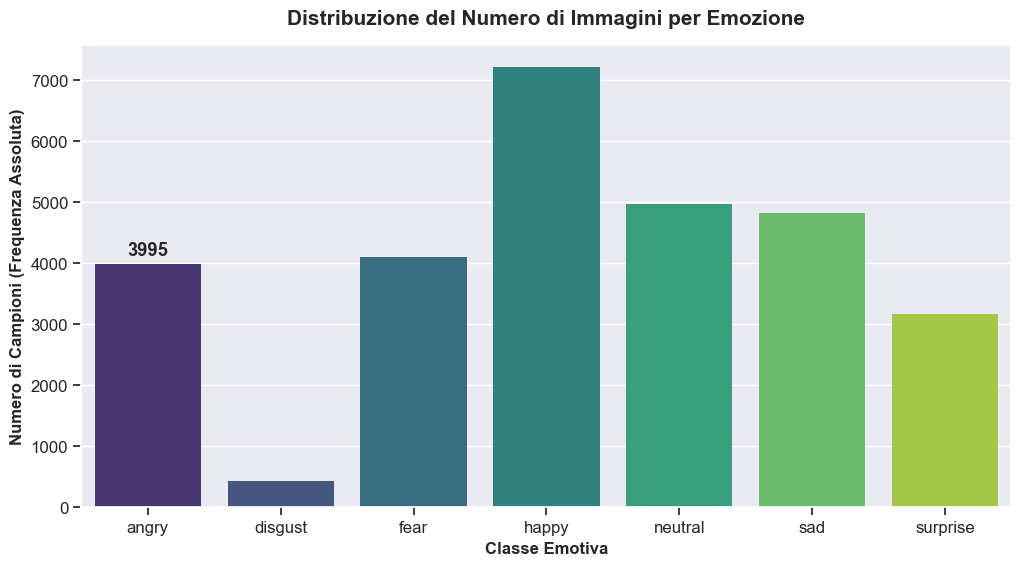

In [2]:
def plot_class_distribution(directory: Path) -> Dict[str, int]:
    """
    Scansiona la directory del dataset, conta le istanze per ogni classe 
    e genera un istogramma della distribuzione.
    
    Args:
        directory (Path): Percorso radice contenente le sottocartelle delle classi.
                          
    Returns:
        Dict[str, int]: Dizionario {nome_emozione: numero_campioni}.
    """
    emotion_counts = {}

    print("\n--- DISTRIBUZIONE DELLE CLASSI ---")
    for emotion_dir in sorted(directory.iterdir()):
        if emotion_dir.is_dir():
            count = sum(1 for _ in emotion_dir.iterdir())
            emotion_counts[emotion_dir.name] = count
            print(f"Classe {emotion_dir.name.upper()}: {count} campioni")

    # Creazione Grafico
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        x=list(emotion_counts.keys()), 
        y=list(emotion_counts.values()), 
        hue=list(emotion_counts.keys()), 
        palette="viridis", 
        legend=False
    )
    
    # Aggiunge il valore numerico esatto sopra ogni barra
    ax.bar_label(ax.containers[0], padding=3, fontweight='bold')
    
    plt.title("Distribuzione del Numero di Immagini per Emozione", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Classe Emotiva", fontsize=12, fontweight='bold')
    plt.ylabel("Numero di Campioni (Frequenza Assoluta)", fontsize=12, fontweight='bold')
    plt.savefig('distribuzione_classi.svg', format='svg', bbox_inches='tight')
    plt.show()
    
    return emotion_counts

counts = plot_class_distribution(base_dir)

In [3]:
def check_images(directory: Path) -> Tuple[int, int, Set[Tuple[int, ...]]]:
    """
    Esegue un Sanity Check ricorsivo su tutti i file per verificare 
    la leggibilità e raccogliere informazioni sulle risoluzioni geometriche.
    
    Args:
        directory (Path): Percorso radice del dataset.
        
    Returns:
        Tuple[int, int, Set[Tuple[int, ...]]]: 
            - Totale file validi.
            - Totale file corrotti.
            - Set delle shape uniche rilevate.
    """
    corrupt_count = 0
    total_count = 0
    unique_shapes = set()
    
    print("Scansione di integrità I/O in corso...")
    
    for emotion_dir in directory.iterdir():
        if not emotion_dir.is_dir(): 
            continue
            
        for img_path in emotion_dir.iterdir():
            total_count += 1
            try:
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"[WARNING] File corrotto o non supportato: {img_path.name}")
                    corrupt_count += 1
                else:
                    unique_shapes.add(img.shape)
            except Exception as e:
                print(f"[ERROR] Eccezione critica su {img_path.name}: {e}")
                corrupt_count += 1
                
    return total_count, corrupt_count, unique_shapes

total, corrupt, shapes = check_images(base_dir)

print("\n--- REPORT DI INTEGRITÀ ---")
print(f"Totale immagini processate: {total}")
print(f"File corrotti rimossi:      {corrupt}")
print(f"Formati tensoriali (H,W,C): {shapes}")

Scansione di integrità I/O in corso...

--- REPORT DI INTEGRITÀ ---
Totale immagini processate: 28709
File corrotti rimossi:      0
Formati tensoriali (H,W,C): {(48, 48, 3)}


## 2. Analisi Visiva Estensiva e Quantitativa
Validata l'infrastruttura, l'analisi si sposta sul dominio visivo. 
Per superare la semplice osservazione soggettiva, applichiamo algoritmi standard di Computer Vision per estrarre tre metriche oggettive che guideranno la fase di *Data Preparation*:

1. **Rumore Strutturale (Face Detection Rate):** Quantifica la percentuale di volti effettivamente riconoscibili dagli algoritmi classici. Un tasso basso indica occlusioni o cropping anomali.
2. **Illuminazione (Pixel Intensity):** Misura le deviazioni statistiche ($\mu, \sigma$) della luminosità per prevenire bias legati all'esposizione fotografica.
3. **Allineamento Spaziale (Laplacian Variance):** Genera i "volti medi" aggregati e ne calcola la nitidezza. Meno i volti sono centrati, più l'immagine media risulterà sfocata (bassa varianza).

--- ANALISI RUMORE STRUTTURALE (FACE DETECTION RATE) ---
Classe ANGRY      -> Face Detection Rate: 38% (su 100 campioni)
Classe DISGUST    -> Face Detection Rate: 45% (su 100 campioni)
Classe FEAR       -> Face Detection Rate: 31% (su 100 campioni)
Classe HAPPY      -> Face Detection Rate: 46% (su 100 campioni)
Classe NEUTRAL    -> Face Detection Rate: 49% (su 100 campioni)
Classe SAD        -> Face Detection Rate: 31% (su 100 campioni)
Classe SURPRISE   -> Face Detection Rate: 39% (su 100 campioni)


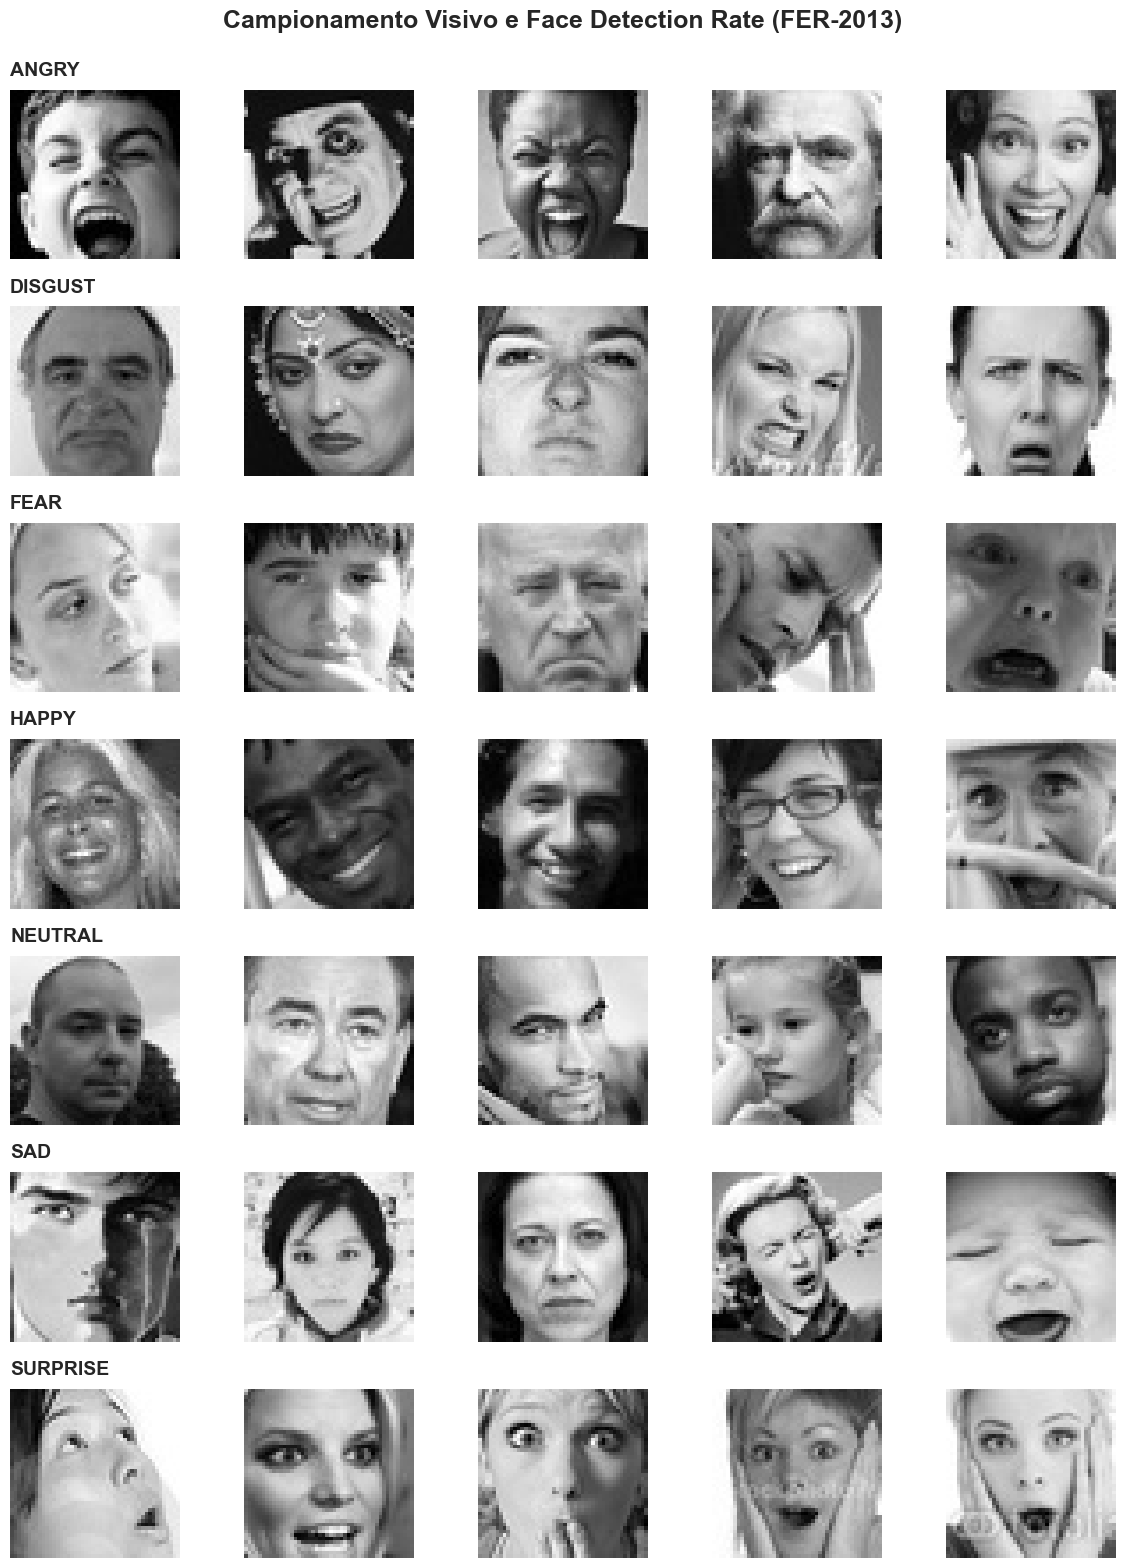

In [4]:
"""
Modulo: Rumore Strutturale e Ispezione Qualitativa.
Utilizza OpenCV Haar Cascades per calcolare il Face Detection Rate su un 
campione rappresentativo, evidenziando le difficoltà intrinseche del dataset.
"""

NUM_SAMPLES = 5
TEST_SIZE = 100
emotions = sorted([d.name for d in base_dir.iterdir() if d.is_dir()])

# Inizializzazione del rilevatore facciale pre-addestrato di OpenCV
cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

fig, axes = plt.subplots(len(emotions), NUM_SAMPLES, figsize=(12, 16))
fig.suptitle('Campionamento Visivo e Face Detection Rate (FER-2013)', fontsize=18, fontweight='bold', y=0.98)

print("--- ANALISI RUMORE STRUTTURALE (FACE DETECTION RATE) ---")

for i, emotion in enumerate(emotions):
    emotion_path = base_dir / emotion
    all_images = list(emotion_path.glob('*'))
    
    # Campionamento per il test statistico
    test_images = random.sample(all_images, min(TEST_SIZE, len(all_images)))
    detected_faces = 0
    
    # Generazione della griglia e calcolo del rate
    for j, img_path in enumerate(test_images):
        img_cv = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        # Test di rilevamento facciale
        faces = face_cascade.detectMultiScale(img_cv, scaleFactor=1.1, minNeighbors=3)
        if len(faces) > 0:
            detected_faces += 1
            
        # Popolamento della griglia grafica
        if j < NUM_SAMPLES:
            axes[i, j].imshow(img_cv, cmap='gray')
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(emotion.upper(), fontsize=14, fontweight='bold', loc='left', pad=10)
                
    print(f"Classe {emotion.upper():<10} -> Face Detection Rate: {detected_faces}% (su {TEST_SIZE} campioni)")

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('grid_visualization.svg', format='svg', bbox_inches='tight')
plt.show()

--- ANALISI DELL'ILLUMINAZIONE (PIXEL INTENSITY) ---
Classe ANGRY      -> Media (μ): 127.42 | Std (σ): 66.32
Classe DISGUST    -> Media (μ): 133.57 | Std (σ): 63.65
Classe FEAR       -> Media (μ): 135.66 | Std (σ): 64.12
Classe HAPPY      -> Media (μ): 128.72 | Std (σ): 63.64
Classe NEUTRAL    -> Media (μ): 125.05 | Std (σ): 66.75
Classe SAD        -> Media (μ): 119.66 | Std (σ): 64.94
Classe SURPRISE   -> Media (μ): 143.72 | Std (σ): 65.11


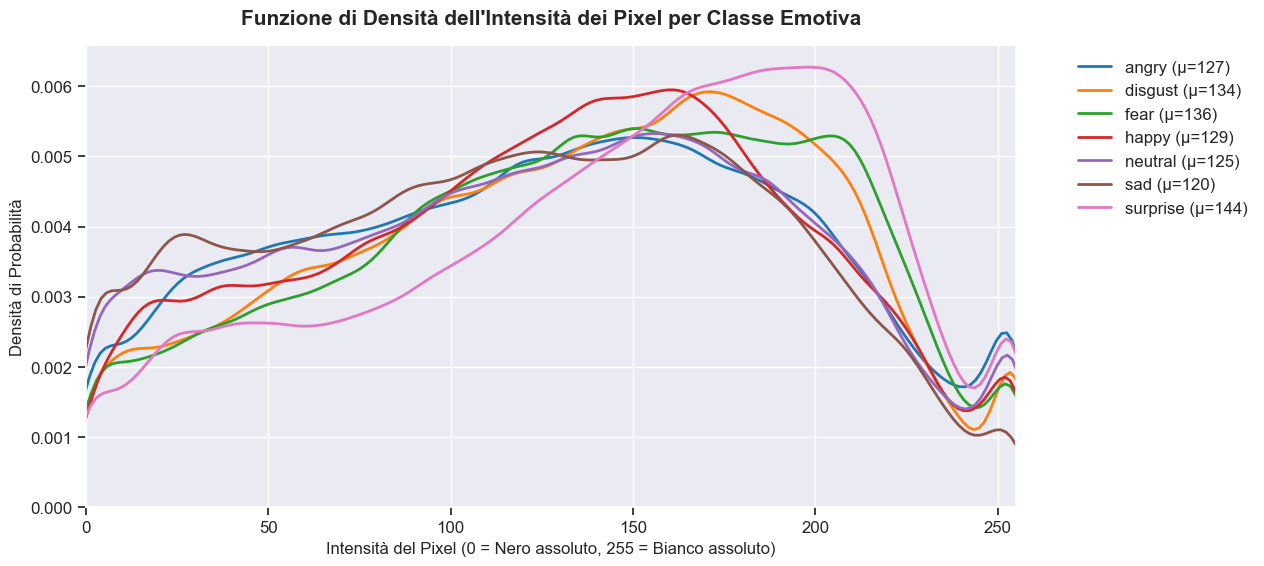

In [5]:
"""
Modulo: Analisi dell'Illuminazione e del Contrasto.
Estrae la distribuzione statistica dell'intensità dei pixel (KDE Plot)
per rilevare squilibri di esposizione luminosa tra le categorie.
"""

print("--- ANALISI DELL'ILLUMINAZIONE (PIXEL INTENSITY) ---")
plt.figure(figsize=(12, 6))

for emotion in emotions:
    emotion_path = base_dir / emotion
    all_images = list(emotion_path.glob('*'))
    sampled_images = random.sample(all_images, min(200, len(all_images)))
    
    pixel_values = []
    for img_path in sampled_images:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixel_values.extend(img.flatten())
    
    # Estrazione metriche di distribuzione
    mean_val = np.mean(pixel_values)
    std_val = np.std(pixel_values)
    print(f"Classe {emotion.upper():<10} -> Media (μ): {mean_val:>6.2f} | Std (σ): {std_val:>5.2f}")
        
    sns.kdeplot(pixel_values, label=f"{emotion} (μ={mean_val:.0f})", linewidth=2)

plt.title("Funzione di Densità dell'Intensità dei Pixel per Classe Emotiva", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Intensità del Pixel (0 = Nero assoluto, 255 = Bianco assoluto)", fontsize=12)
plt.ylabel("Densità di Probabilità", fontsize=12)
plt.xlim(0, 255)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('pixel_intensity.svg', format='svg', bbox_inches='tight')
plt.show()

--- ANALISI DELL'ALLINEAMENTO SPAZIALE (LAPLACIAN VARIANCE) ---
Classe ANGRY      -> Varianza del Laplaciano: 5.83
Classe DISGUST    -> Varianza del Laplaciano: 13.81
Classe FEAR       -> Varianza del Laplaciano: 6.69
Classe HAPPY      -> Varianza del Laplaciano: 6.26
Classe NEUTRAL    -> Varianza del Laplaciano: 7.49
Classe SAD        -> Varianza del Laplaciano: 4.25
Classe SURPRISE   -> Varianza del Laplaciano: 14.41


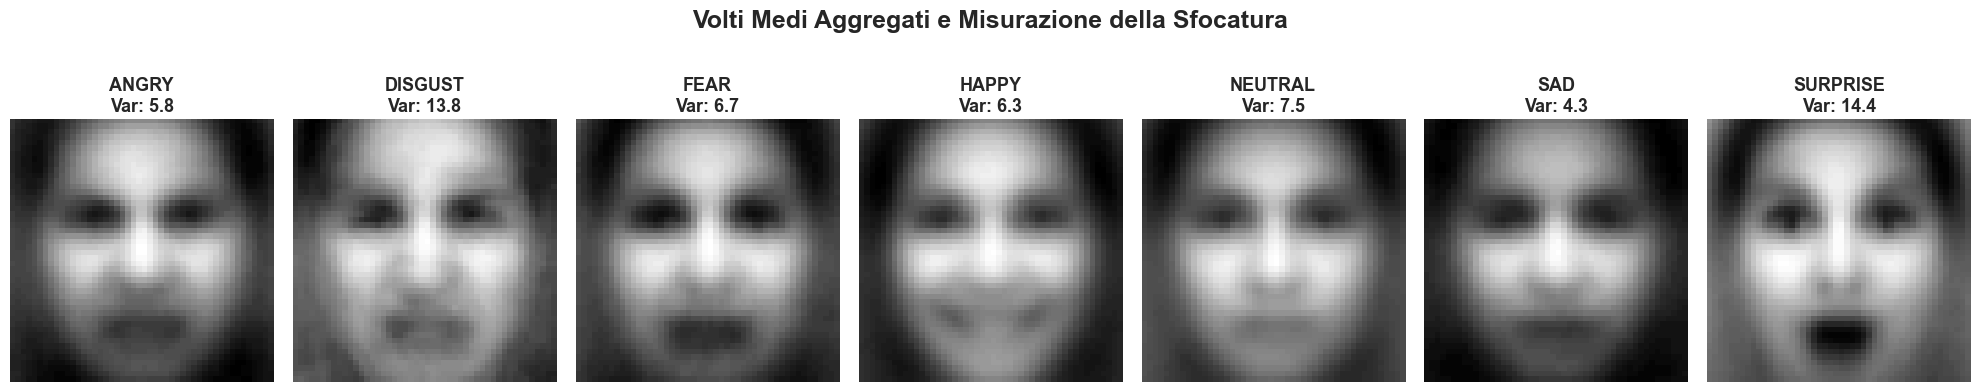

In [6]:
"""
Modulo: Allineamento Spaziale e Volti Medi.
Aggrega i campioni per creare un volto rappresentativo medio. Applica il filtro
Laplaciano per calcolare la varianza (nitidezza): valori bassi indicano una 
severa mancanza di allineamento facciale nel dataset.
"""

print("--- ANALISI DELL'ALLINEAMENTO SPAZIALE (LAPLACIAN VARIANCE) ---")
fig, axes = plt.subplots(1, len(emotions), figsize=(20, 4))
fig.suptitle('Volti Medi Aggregati e Misurazione della Sfocatura', fontsize=18, fontweight='bold', y=1.05)

for i, emotion in enumerate(emotions):
    emotion_path = base_dir / emotion
    all_images = list(emotion_path.glob('*'))
    
    # Matrice di accumulo in virgola mobile per prevenire l'overflow
    avg_img_float = np.zeros((48, 48), dtype=np.float64)
    valid_images = 0
    
    for img_path in all_images:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            avg_img_float += img
            valid_images += 1
            
    # Normalizzazione per ottenere il volto medio reale
    avg_img = (avg_img_float / valid_images).astype(np.uint8)
    
    # Calcolo della Varianza del Laplaciano (Misura di nitidezza/sfocatura)
    laplacian_var = cv2.Laplacian(avg_img, cv2.CV_64F).var()
    print(f"Classe {emotion.upper():<10} -> Varianza del Laplaciano: {laplacian_var:.2f}")
    
    axes[i].imshow(avg_img, cmap='gray')
    axes[i].set_title(f"{emotion.upper()}\nVar: {laplacian_var:.1f}", fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('average_faces.svg', format='svg', bbox_inches='tight')
plt.show()

## Conclusioni della Fase 1

L'analisi quantitativa ha fatto emergere criticità strutturali che impongono precise scelte di *Feature Engineering* e *Model Design*:

1. **Gestione Class Imbalance:** Il rapporto di $16:1$ tra la classe maggioritaria (*Happy*) e quella minoritaria (*Disgust*) invalida l'uso dell'Accuratezza come metrica guida. Il training richiederà logiche di **Cost-Sensitive Learning** (pesatura matematica delle classi) e la valutazione avverrà tramite F1-Score.
2. **Integrità Strutturale:** L'assenza di file corrotti permette di caricare i dati in sicurezza. La dimensionalità nativa $(48, 48, 3)$ contiene canali RGB ridondanti, forzeremo la lettura in scala di grigi (*Grayscale*) per abbattere il carico computazionale.
3. **Generalizzazione del Rumore Strutturale:** Il Face Detection Rate estremamente critico (min. 31% su *Fear*) certifica l'alta presenza di occlusioni e clipping. È tassativo sviluppare una robusta pipeline di **Data Augmentation** spaziale (traslazioni e zoom casuali) per indurre il modello a tollerare il rumore.
4. **Normalizzazione dell'Esposizione:** La forte disparità di illuminazione (es. classe *Surprise* anomalamente sovraesposta) rischia di creare shortcut predittivi (il modello associa la luce all'emozione). L'inserimento di un layer di **Rescaling** $\in [0, 1]$ è obbligatorio.
5. **Invarianza Traslazionale:** I volti medi restituiscono varianze del Laplaciano bassissime (sfocatura grave da disallineamento geometrico). Ciò dimostra che i pixel degli occhi/bocca non si trovano mai nelle stesse coordinate spaziali. Questo fattore rende inutilizzabili le reti classiche fisse e decreta la necessità assoluta di una **Rete Neurale Convoluzionale (CNN)** dotata di filtri `MaxPooling` per estrarre feature localmente invarianti.